# Example-22: Fitted frequency (method)

In [1]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# In this example frequency (and its spread) is estimated for each signal using OLS/WLS fit
# Fit for each signal is performed using DTFT spectrum points near the expected maximum
# This provides estimation of frequency and its spread for a signal
# Data across signals can be used to fit (optionaly with weights) overall frequency

# These estimations are compared with estimations from multiple noise realizations
# And with estimations from time shifted signals

In [4]:
# Compute reference frequency
# Note, without noise, frequencies for different BPMs are equal within machine precision (for given length and window)

# Set parameters (signal length, data type and device)

length = 4096

# Set window

w = Window(length, 'cosine_window', 4.0, dtype=dtype, device=device)

# Load TbT

d = Data.from_file(54, w, '../virtual_tbt.npy')

# Remove mean and apply window

d.window_remove_mean()
d.window_apply()

# Compute reference frequency

f = Frequency(d)
f('parabola')
m_ref, s_ref = f.frequency.mean().cpu().item(), f.frequency.std().cpu().item()

# Reset work

d.reset()

# Print results

print(f'{m_ref:<16.12}')
print(f'{s_ref:<16.12}')

0.463116901263  
1.22950124638e-16


In [5]:
# Set noise parameters

# All BPMs have different noise sigma

std = 1.0E-4*(4.0*torch.rand(54) + 1.0)

# One BPM has increased noise level

std[0] = 3.0E-3

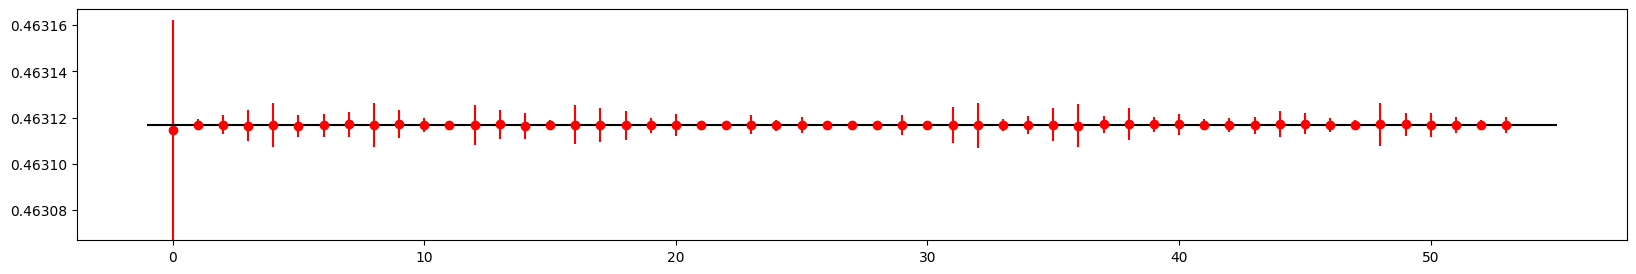

In [6]:
# Estimate spread for different noise realizations

# Iterate over noise realizations

table = []
count = 1024

for _ in range(count):
    w = Window(1024, 'cosine_window', 1.0, dtype=dtype, device=device)
    t = Data.from_data(w, d.data[:, :len(w)])
    t.add_noise(std)
    t.window_remove_mean()
    t.window_apply()
    f = Frequency(t)
    f('parabola')
    table.append(f.frequency)
    
table = torch.stack(table)

# Set mean and spread values for each BPM

m1, s1 = table.mean(0).cpu(), table.std(0).cpu()

# Plot results

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), m1, yerr=s1, c='red', fmt='o')
plt.ylim((m_ref - 5.0E-5, m_ref + 5.0E-5))
plt.hlines(m_ref, -1, 55, colors='black')
plt.show()

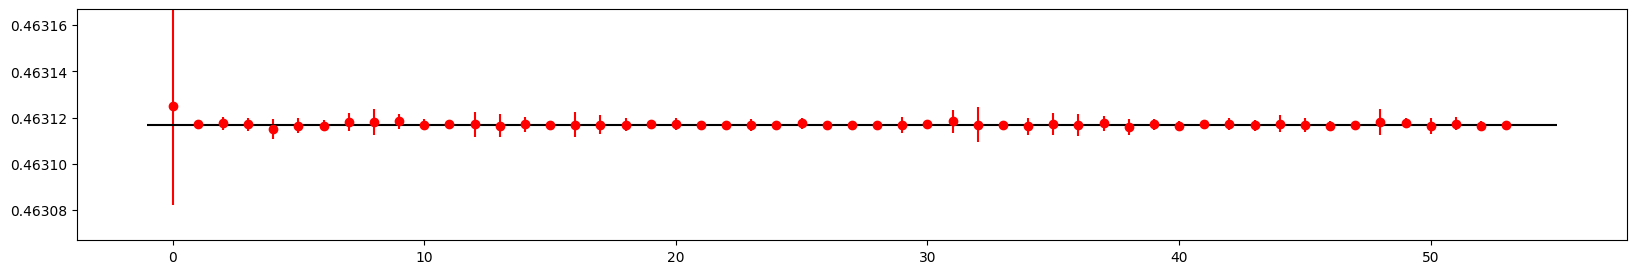

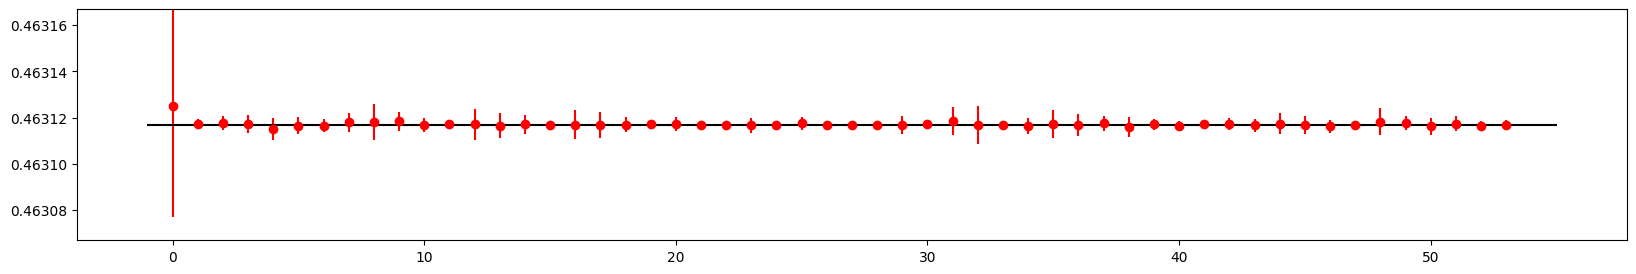

In [7]:
# Estimate spread from time shifted signals

# Load data

w = Window(length, dtype=dtype, device=device)
d = Data.from_file(54, w, '../virtual_tbt.npy')
d.add_noise(std)

# Iterate over signals

table = []

w = Window(1024, dtype=dtype, device=device)
for idx in range(d.size):
    t = d.make_matrix(length=w.length, shift=16, signal=d.work[idx])
    t = Data.from_data(w, t)
    t.window_remove_mean()
    t.window_apply()
    f = Frequency(t)
    f('parabola')
    table.append(f.frequency)
    
table = torch.stack(table)

# Set mean and spread values for each BPM
# Note, spread is computed as std

m2, s2 = table.mean(1).cpu(), table.std(1).cpu()

# Plot results

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), m2, yerr=s2, c='red', fmt='o')
plt.ylim((m_ref - 5.0E-5, m_ref + 5.0E-5))
plt.hlines(m_ref, -1, 55, colors='black')
plt.show()

# Set mean and spread values for each BPM
# Note, spread is computed from  peak-to-peak

f_min = table.min(1).values
f_max = table.max(1).values

m2 = table.mean(1).cpu()
s2 = 1/4.0*(f_max - f_min).cpu()

# Plot results

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), m2, yerr=s2, c='red', fmt='o')
plt.ylim((m_ref - 5.0E-5, m_ref + 5.0E-5))
plt.hlines(m_ref, -1, 55, colors='black')
plt.show()

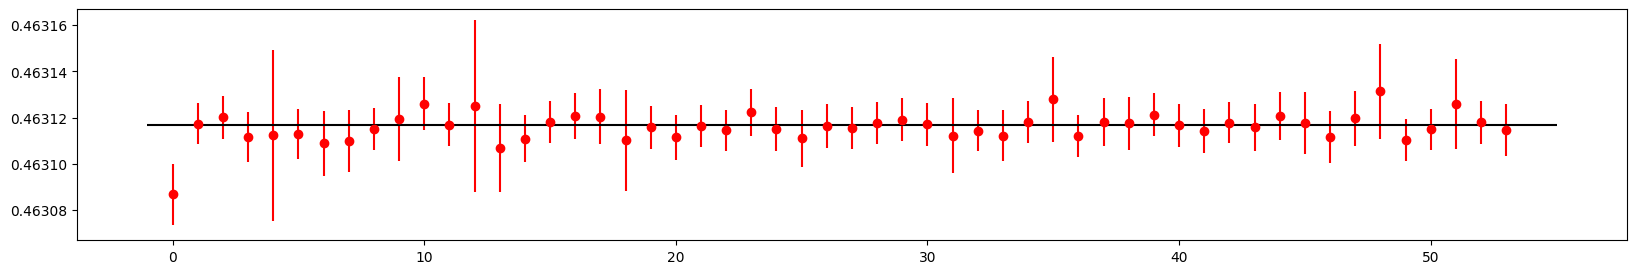

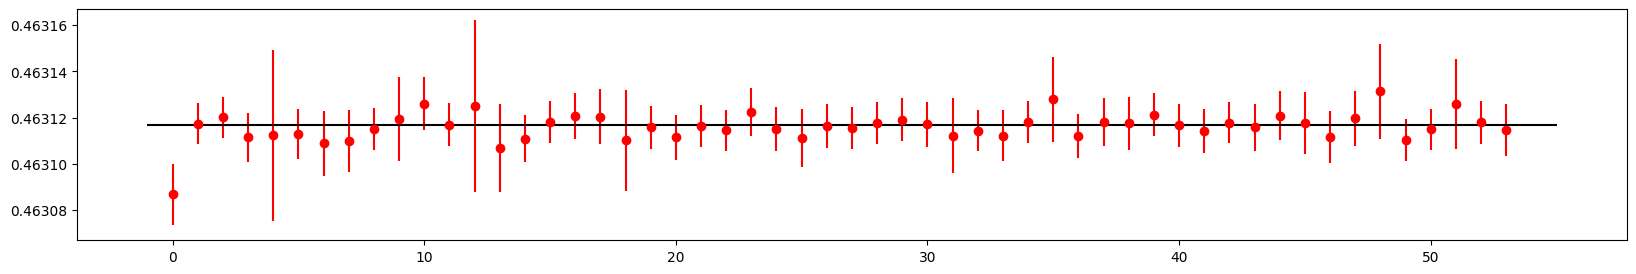

In [8]:
# Estimate spread from fit

# Load data

w = Window(1024, 'cosine_window', 1.0, dtype=dtype, device=device)
d = Data.from_file(54, w, '../virtual_tbt.npy')
d.add_noise(std)

# Remove mean and apply window

d.window_remove_mean()
d.window_apply()

# Compute frequencies

f = Frequency(d)
f('parabola')

# Fit (ols)

out = f.compute_fitted_frequency(fraction=0.995, mode='ols')

# Set fitted frequencies and spread

m3, s3 = out.T.cpu()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), m3, yerr=s3, c='red', fmt='o')
plt.ylim((m_ref - 5.0E-5, m_ref + 5.0E-5))
plt.hlines(m_ref, -1, 55, colors='black')
plt.show()

# Fit (wls)

out = f.compute_fitted_frequency(fraction=0.995, mode='wls', std=std)

# Set fitted frequencies and spread

m3, s3 = out.T.cpu()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), m3, yerr=s3, c='red', fmt='o')
plt.ylim((m_ref - 5.0E-5, m_ref + 5.0E-5))
plt.hlines(m_ref, -1, 55, colors='black')
plt.show()

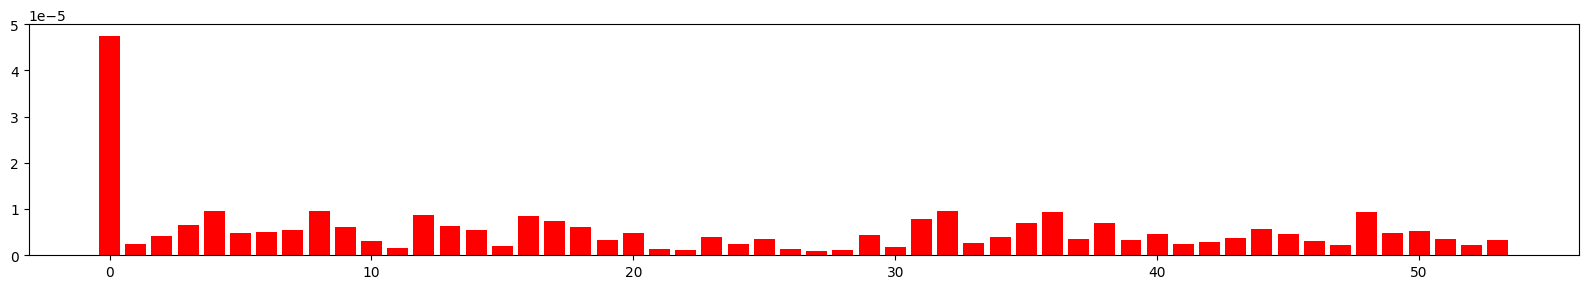

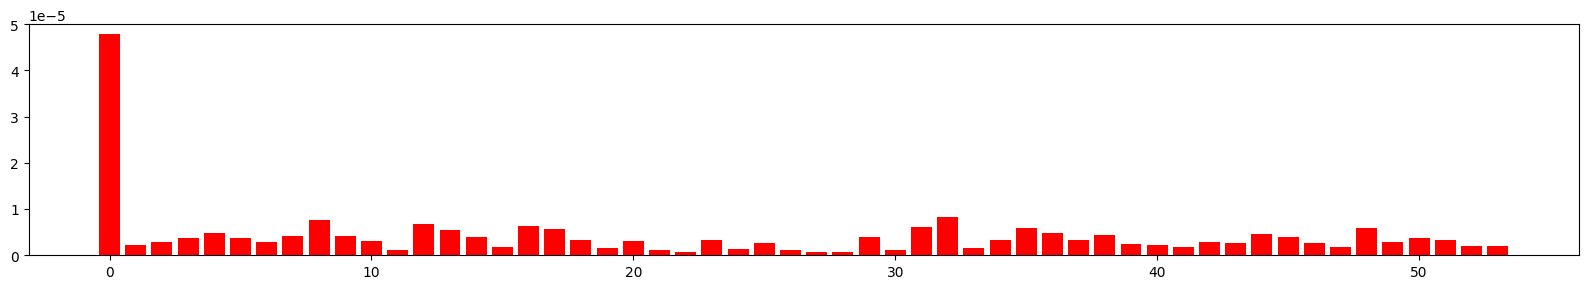

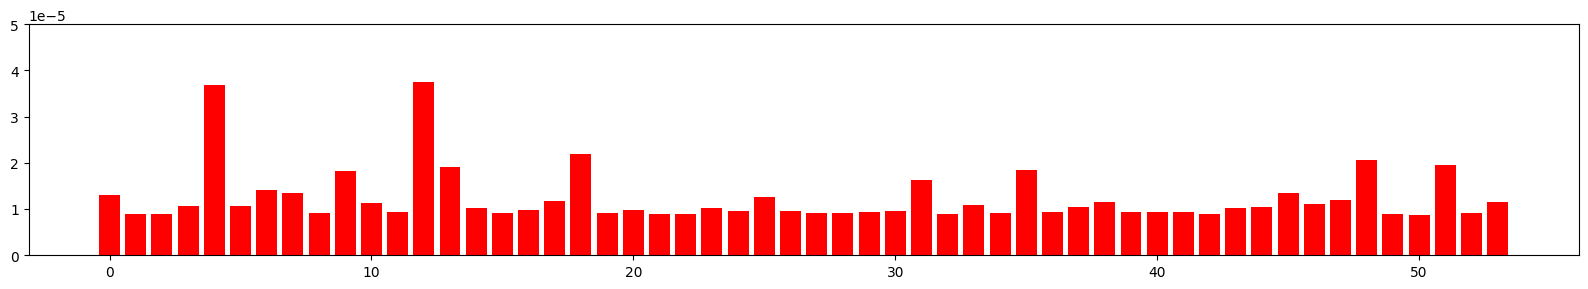

In [9]:
# Compare

plt.figure(figsize=(20, 3))
plt.bar(range(54), s1, color='red')
plt.ylim((0, 5.0E-5))
plt.show()

plt.figure(figsize=(20, 3))
plt.bar(range(54), s2, color='red')
plt.ylim((0, 5.0E-5))
plt.show()

plt.figure(figsize=(20, 3))
plt.bar(range(54), s3, color='red')
plt.ylim((0, 5.0E-5))
plt.show()

In [10]:
# Compare direct mean

print(abs(m_ref - m1.mean().cpu().item()))
print(abs(m_ref - m2.mean().cpu().item()))
print(abs(m_ref - m3.mean().cpu().item()))

7.114944305941506e-08
2.4723939850979093e-07
8.879558154317735e-07


In [11]:
# Fit frequency for all BPMs

from statsmodels.api import OLS, WLS

X = numpy.ones(54).reshape(1, 54).T
y = m1.numpy()
w = (1/s1**2).cpu().numpy()

ols1 = OLS(y, X).fit()
wls1 = WLS(y, X, w).fit()

print(f'ols: err={abs(m_ref - ols1.params.item()):12.8}, std={ols1.bse.item():12.8}')
print(f'wls: err={abs(m_ref - wls1.params.item()):12.8}, std={wls1.bse.item():12.8}')

ols: err=7.1149443e-08, std=4.8068141e-08
wls: err=1.6452003e-09, std=1.4705815e-08


In [12]:
# Fit frequency for all BPMs using 'shifted' weights

from statsmodels.api import OLS, WLS

X = numpy.ones(54).reshape(1, 54).T
y = m2.numpy()
w = (1/s2**2).cpu().numpy()

ols2 = OLS(y, X).fit()
wls2 = WLS(y, X, w).fit()

print(f'ols: err={abs(m_ref - ols2.params.item()):12.8}, std={ols2.bse.item():12.8}')
print(f'wls: err={abs(m_ref - wls2.params.item()):12.8}, std={wls2.bse.item():12.8}')

ols: err=2.472394e-07, std=1.6700513e-07
wls: err=7.1275738e-09, std=4.1777318e-08


In [13]:
# Fit frequency for all BPMs using 'fitted' weights

from statsmodels.api import OLS, WLS

X = numpy.ones(54).reshape(1, 54).T
y = m3.numpy()
w = (1/s3**2).cpu().numpy()

ols3 = OLS(y, X).fit()
wls3 = WLS(y, X, w).fit()

print(f'ols: err={abs(m_ref - ols3.params.item()):12.8}, std={ols3.bse.item():12.8}')
print(f'wls: err={abs(m_ref - wls3.params.item()):12.8}, std={wls3.bse.item():12.8}')

ols: err=8.8795582e-07, std=8.6971144e-07
wls: err=9.5590165e-07, std=6.9033008e-07
